In [26]:
"""Time-to-target comparison — FbR_M01569522, Day36: NoSoundCue vs FloorRotation.

Reads ExperimentEvents straight from the two session directories (no data_conduit /
SessionSettings / HARP yaml needed) and compares the per-trial "time to target".

Trial event sequence and the segments derived from it:

    Start Trial --setup--> Target zone available --search--> Target zone triggered --poke_latency--> Poke
    |<-------------------- outbound  =  time to target -------------------->|

    setup_duration   start  -> tz available    (rig rotation / reset)
    search_duration  tz available -> triggered (pure search to reach the target)
    outbound         start  -> tz triggered    (TIME TO TARGET = setup + search)  <- headline metric
    poke_latency     tz triggered -> poke       (decision at the port; the older "TTP")

Three views: (1) distribution + Mann-Whitney, (2) within-session trend,
(3) success rate as a function of time to target.
"""

'Time-to-target comparison — FbR_M01569522, Day36: NoSoundCue vs FloorRotation.\n\nReads ExperimentEvents straight from the two session directories (no data_conduit /\nSessionSettings / HARP yaml needed) and compares the per-trial "time to target".\n\nTrial event sequence and the segments derived from it:\n\n    Start Trial --setup--> Target zone available --search--> Target zone triggered --poke_latency--> Poke\n    |<-------------------- outbound  =  time to target -------------------->|\n\n    setup_duration   start  -> tz available    (rig rotation / reset)\n    search_duration  tz available -> triggered (pure search to reach the target)\n    outbound         start  -> tz triggered    (TIME TO TARGET = setup + search)  <- headline metric\n    poke_latency     tz triggered -> poke       (decision at the port; the older "TTP")\n\nThree views: (1) distribution + Mann-Whitney, (2) within-session trend,\n(3) success rate as a function of time to target.\n'

In [36]:
#=== Setup — imports, session paths, parsers
#
# Data lives on the Elements drive (the other notebooks' /home/callum/... path is dead here).
# The FloorRotation folder is Day36-43 (not -42).

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = Path("/media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput/Test/FbR_M01569522")
SESSIONS = {
    "NoSoundCue (control)":     BASE / "Day36-42NoSoundCue"    / "2026-06-26T150917Z",
    "FloorRotation (scramble)": BASE / "Day36-43FloorRotation" / "2026-06-26T152415Z",
}
COLORS = {"NoSoundCue (control)": "#1f77b4", "FloorRotation (scramble)": "#d62728"}

# Poke payload: "Poke: {Success=True, ChosenPort=15, CorrectPort=15-}"
_POKE = re.compile(
    r"Poke:\s*\{Success=(?P<success>True|False),\s*"
    r"ChosenPort=(?P<chosen>-?\d+),\s*CorrectPort=(?P<correct>\d+)-?\}"
)

def parse_poke(value):
    """Pull success / chosen_port / correct_port / outcome out of a Poke event string."""
    m = _POKE.search(value)
    if m is None:
        return {}
    chosen, correct = int(m["chosen"]), int(m["correct"])
    success = m["success"] == "True"
    outcome = "success" if success else ("miss" if chosen == -1 else "fail")
    return {"success": success, "chosen_port": chosen, "correct_port": correct, "outcome": outcome}

In [38]:
#=== Load events and build one row per trial
#
# ExperimentEvents CSVs have columns Seconds,Value. Value contains commas (Poke payload),
# so split on the FIRST comma only. A session may span >1 CSV (clock rollover) -> concat
# and sort by Seconds. build_trials mirrors utils/trial_table.py::build_trial_table.

def load_events(session_dir):
    recs = []
    for csv in sorted((session_dir / "ExperimentEvents").glob("*.csv")):
        for line in csv.read_text().splitlines():
            if not line or line.startswith("Seconds,"):
                continue
            sec, _, val = line.partition(",")
            try:
                recs.append((float(sec), val))
            except ValueError:
                continue
    return (pd.DataFrame(recs, columns=["Seconds", "Value"])
              .sort_values("Seconds").reset_index(drop=True))

def build_trials(events):
    rows, cur = [], None
    for sec, val in zip(events["Seconds"].to_numpy(), events["Value"].astype(str).to_numpy()):
        if "Start Trial" in val:              # open trial (drop any unfinished one)
            cur = {"start_time": sec}
            continue
        if cur is None:
            continue
        if "Target zone available" in val:
            cur["tz_available_time"] = sec
        if "Target zone triggered" in val:
            cur["tz_triggered_time"] = sec
        if val.startswith("Poke:"):           # close trial
            cur["end_time"] = sec
            cur.update(parse_poke(val))
            rows.append(cur)
            cur = None
    t = pd.DataFrame(rows)
    t["trial_index"]     = range(1, len(t) + 1)
    t["setup_duration"]  = t["tz_available_time"] - t["start_time"]
    t["search_duration"] = t["tz_triggered_time"] - t["tz_available_time"]
    t["outbound"]        = t["tz_triggered_time"] - t["start_time"]      # = time to target
    t["poke_latency"]    = t["end_time"] - t["tz_triggered_time"]
    return t

tables = {label: build_trials(load_events(d)) for label, d in SESSIONS.items()}
labels = list(tables)
for label, t in tables.items():
    print(f"{label:26s} trials={len(t):3d}  outcomes={t['outcome'].value_counts().to_dict()}")

NoSoundCue (control)       trials= 63  outcomes={'success': 55, 'miss': 7, 'fail': 1}
FloorRotation (scramble)   trials= 47  outcomes={'success': 25, 'miss': 18, 'fail': 4}


In [39]:
#=== 1. Time-to-target distribution — summary stats + Mann-Whitney
#
# Durations are skewed, so use a rank test (Mann-Whitney U) rather than a t-test.
# Also reports the other three segments for context.

def describe(series, label):
    s = series.dropna()
    return {"session": label, "n": len(s), "mean": s.mean(), "median": s.median(),
            "std": s.std(), "q25": s.quantile(.25), "q75": s.quantile(.75),
            "min": s.min(), "max": s.max()}

METRIC = "outbound"   # time to target
summary = pd.DataFrame([describe(tables[l][METRIC], l) for l in labels]).set_index("session")
a, b = tables[labels[0]][METRIC].dropna(), tables[labels[1]][METRIC].dropna()
u, p_mwu = stats.mannwhitneyu(a, b, alternative="two-sided")

pd.set_option("display.float_format", lambda x: f"{x:.2f}")
print("TIME TO TARGET (outbound: Start Trial -> Target zone triggered), seconds\n")
print(summary.to_string())
print(f"\nMann-Whitney U: U={u:.0f}, p={p_mwu:.3g}  |  "
      f"median {a.median():.2f}s vs {b.median():.2f}s  ({b.median()/a.median():.2f}x)")

print("\nOther segments (median control -> floor, Mann-Whitney p):")
for m, name in [("search_duration", "pure search (available->triggered)"),
                ("setup_duration",  "setup/rotation (start->available)"),
                ("poke_latency",    "poke latency / old 'TTP' (triggered->poke)")]:
    aa, bb = tables[labels[0]][m].dropna(), tables[labels[1]][m].dropna()
    _, pp = stats.mannwhitneyu(aa, bb, alternative="two-sided")
    print(f"  {name:42s} {aa.median():5.2f} -> {bb.median():5.2f}s  (p={pp:.3g})")

TIME TO TARGET (outbound: Start Trial -> Target zone triggered), seconds

                           n  mean  median   std   q25   q75  min   max
session                                                                
NoSoundCue (control)      63 10.90    8.97  8.03  7.41 11.12 2.06 49.49
FloorRotation (scramble)  47 15.70   13.82 11.93 10.47 17.42 4.24 85.56

Mann-Whitney U: U=764, p=1.52e-05  |  median 8.97s vs 13.82s  (1.54x)

Other segments (median control -> floor, Mann-Whitney p):
  pure search (available->triggered)          2.77 ->  5.57s  (p=0.00125)
  setup/rotation (start->available)           7.05 ->  7.73s  (p=0.0254)
  poke latency / old 'TTP' (triggered->poke)  2.83 ->  4.20s  (p=0.00011)


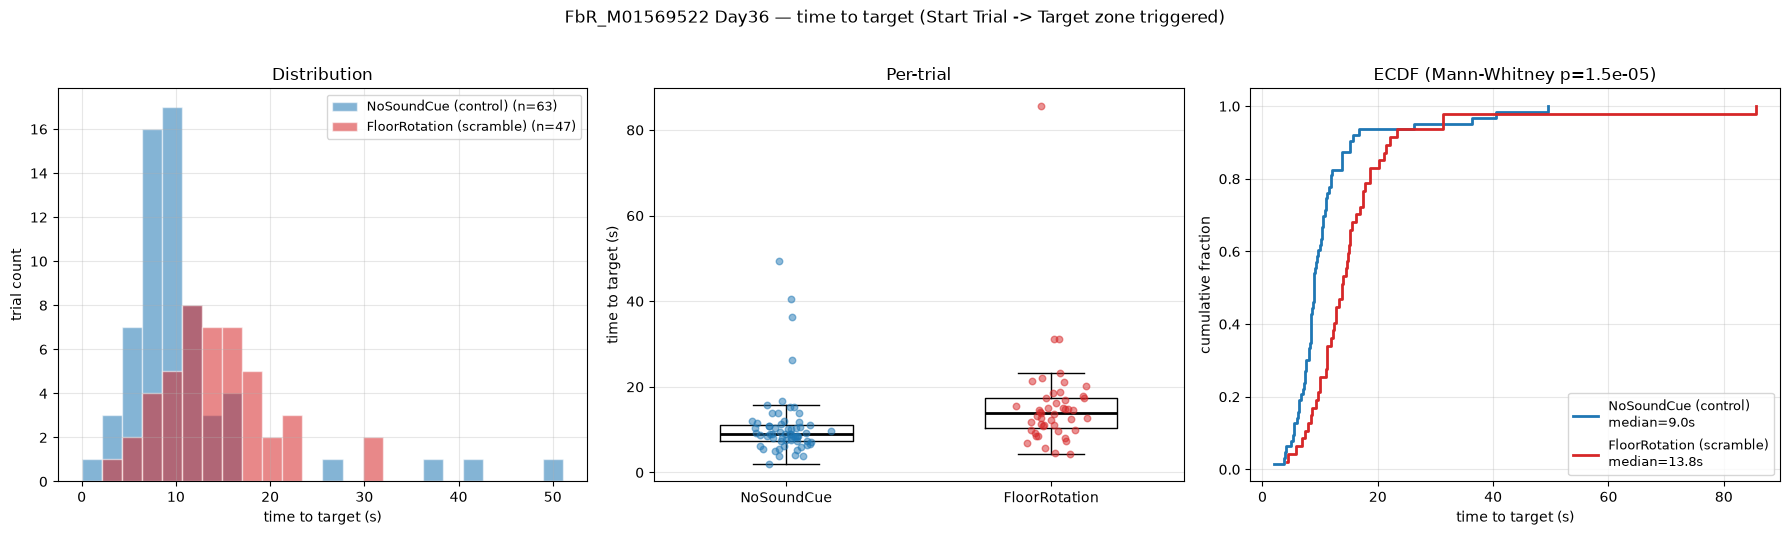

In [40]:
#=== Plot 1 — time-to-target distribution: histogram, box+strip, ECDF

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

bins = np.linspace(0, np.nanpercentile(pd.concat([a, b]), 99) * 1.05, 25)
for l, v in [(labels[0], a), (labels[1], b)]:
    axes[0].hist(v, bins=bins, alpha=.55, color=COLORS[l], edgecolor="white", label=f"{l} (n={len(v)})")
axes[0].set(xlabel="time to target (s)", ylabel="trial count", title="Distribution")
axes[0].legend(fontsize=9); axes[0].grid(alpha=.3)

axes[1].boxplot([a.values, b.values], tick_labels=[l.split()[0] for l in labels],
                showfliers=False, widths=.5, medianprops=dict(color="black", lw=2))
for i, (l, v) in enumerate([(labels[0], a), (labels[1], b)], start=1):
    axes[1].scatter(np.random.normal(i, .06, len(v)), v, alpha=.5, s=22, color=COLORS[l], zorder=3)
axes[1].set(ylabel="time to target (s)", title="Per-trial"); axes[1].grid(alpha=.3, axis="y")

for l, v in [(labels[0], a), (labels[1], b)]:
    xs = np.sort(v.values); ys = np.arange(1, len(xs) + 1) / len(xs)
    axes[2].step(xs, ys, where="post", color=COLORS[l], lw=2, label=f"{l}\nmedian={v.median():.1f}s")
axes[2].set(xlabel="time to target (s)", ylabel="cumulative fraction",
            title=f"ECDF (Mann-Whitney p={p_mwu:.2g})")
axes[2].legend(fontsize=9); axes[2].grid(alpha=.3)

fig.suptitle("FbR_M01569522 Day36 — time to target (Start Trial -> Target zone triggered)", y=1.02)
fig.tight_layout(); plt.show()

In [41]:
#=== 2. Within-session trend — does time to target climb across trials (fatigue)?
#
# Spearman(time-to-target vs trial #) plus first-half vs second-half medians / success.

for l in labels:
    s = tables[l]
    half = len(s) // 2
    first, second = s.iloc[:half], s.iloc[half:]
    rho, p = stats.spearmanr(s["trial_index"], s["outbound"])
    succ = lambda d: (d["outcome"] == "success").mean()
    print(f"{l} ({len(s)} trials)")
    print(f"  Spearman(TTT vs trial #): rho={rho:+.2f}, p={p:.3g}")
    print(f"  1st half: median TTT={first['outbound'].median():5.2f}s  success={succ(first):.0%}")
    print(f"  2nd half: median TTT={second['outbound'].median():5.2f}s  success={succ(second):.0%}\n")

NoSoundCue (control) (63 trials)
  Spearman(TTT vs trial #): rho=+0.17, p=0.185
  1st half: median TTT= 8.40s  success=94%
  2nd half: median TTT= 9.56s  success=81%

FloorRotation (scramble) (47 trials)
  Spearman(TTT vs trial #): rho=-0.19, p=0.194
  1st half: median TTT=14.58s  success=57%
  2nd half: median TTT=13.77s  success=50%



In [43]:
#=== 3. Success rate as a function of time to target — matched bins
#
# Bin trials by time to target; compare success rate per bin. Matched test = chi2 of
# success vs session restricted to bins with >=4 trials in BOTH sessions.

df = pd.concat([tables[l].assign(session=l) for l in labels], ignore_index=True)
df["success"] = (df["outcome"] == "success").astype(int)

edges  = np.array([0, 6, 9, 12, 16, 25, np.inf])
binlbl = ["<6", "6-9", "9-12", "12-16", "16-25", ">25"]
df["ttt_bin"] = pd.cut(df["outbound"], bins=edges, labels=binlbl, right=False)

g = df.groupby(["ttt_bin", "session"], observed=True).agg(
        n=("success", "size"), succ=("success", "mean")).reset_index()
print("n trials per bin:")
print(g.pivot(index="ttt_bin", columns="session", values="n").to_string(), "\n")
print("success rate per bin (%):")
print((g.pivot(index="ttt_bin", columns="session", values="succ") * 100).round(0).astype("Int64").to_string())

piv_n = g.pivot(index="ttt_bin", columns="session", values="n")
both  = piv_n.dropna()[(piv_n.dropna() >= 4).all(axis=1)]
sub   = df[df["ttt_bin"].isin(both.index)]
chi2, p_match, _, _ = stats.chi2_contingency(pd.crosstab(sub["session"], sub["success"]))
print(f"\nMatched on time-to-target (bins {list(both.index)}):")
for l in labels:
    ss = sub[sub.session == l]
    print(f"  {l}: success {ss['success'].mean():.0%} (n={len(ss)})")
print(f"  chi2 p (success vs session, matched on search time) = {p_match:.3g}")

n trials per bin:
session  FloorRotation (scramble)  NoSoundCue (control)
ttt_bin                                                
<6                              3                     8
6-9                             5                    25
9-12                            9                    19
12-16                          15                     6
16-25                          12                     1
>25                             3                     4 

success rate per bin (%):
session  FloorRotation (scramble)  NoSoundCue (control)
ttt_bin                                                
<6                             67                    88
6-9                            60                    88
9-12                           67                    95
12-16                          40                    83
16-25                          50                     0
>25                            67                    75

Matched on time-to-target (bins ['6-9', '9-12', '12-16'])

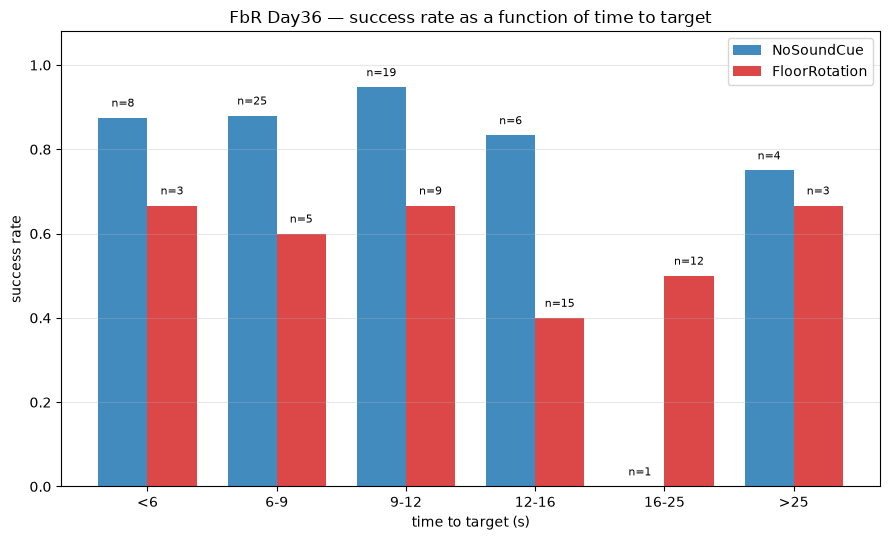

In [44]:
#=== Plot 2 — success rate as a function of time to target

fig, ax = plt.subplots(figsize=(9, 5.5))
x, w = np.arange(len(binlbl)), 0.38
for i, l in enumerate(labels):
    s = df[df.session == l]
    rates = [s.loc[s.ttt_bin == bl, "success"].mean() if (s.ttt_bin == bl).any() else np.nan for bl in binlbl]
    ns    = [int((s.ttt_bin == bl).sum()) for bl in binlbl]
    ax.bar(x + (i - .5) * w, rates, w, color=COLORS[l], alpha=.85, label=l.split()[0])
    for xi, r, nn in zip(x + (i - .5) * w, rates, ns):
        if nn:
            ax.text(xi, (r if np.isfinite(r) else 0) + .02, f"n={nn}", ha="center", va="bottom", fontsize=8)
ax.set(xticks=x, xlabel="time to target (s)", ylabel="success rate", ylim=(0, 1.08),
       title="FbR Day36 — success rate as a function of time to target")
ax.set_xticklabels(binlbl); ax.legend(); ax.grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

In [45]:
#=== Save the per-trial table next to the notebook

OUT = Path.cwd()
df[["session", "trial_index", "outcome",
    "setup_duration", "search_duration", "outbound", "poke_latency"]].to_csv(
    OUT / "time_to_target_FbR_Day36_trials.csv", index=False)
print("wrote", OUT / "time_to_target_FbR_Day36_trials.csv")

wrote /home/sepi/dataconduit_workspace/data-conduit/Q_C_Analysis_Workflow/notebooks/time_to_target_FbR_Day36_trials.csv
